# Ames Housing Dataset - Análisis Pre-ML

## Descripción del Dataset
El dataset Ames Housing contiene información detallada sobre ventas de propiedades residenciales en Ames, Iowa (USA) entre 2006-2010. Incluye 82 variables que describen características físicas, ubicación, calidad y condiciones de venta de las propiedades.

**Variables principales:**
- Características físicas: área del lote, área habitable, número de habitaciones, baños
- Calidad: calidad exterior, calidad de cocina, calidad del sótano
- Ubicación: vecindario, zonificación
- Temporal: año de construcción, año de venta

## Objetivo de Machine Learning
**Regresión**: Predecir el precio de venta de una propiedad (`SalePrice`)

**Target**: `SalePrice` (precio de venta en dólares)

**Features potenciales**:
- Numéricas: área total, número de habitaciones, año de construcción
- Categóricas: vecindario, calidad de materiales, tipo de vivienda

## PASO 1: Cargar Dataset

In [79]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# Cargar dataset
df = pd.read_csv('train.csv')

# Normalizar nombres de columnas (quitar espacios)
df.columns = df.columns.str.replace(' ', '')

print("✅ Dataset cargado correctamente")

✅ Dataset cargado correctamente


## PASO 2: Ver Estructura del Dataset

In [80]:
# Primeras filas
print("=== PRIMERAS 5 FILAS ===")
df.head()

=== PRIMERAS 5 FILAS ===


,Order,PID,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,534,531363010,20,RL,80.0,9605,Pave,NaN,Reg,Lvl,...,0,NaN,NaN,NaN,0,4,2009,WD,Normal,159000
1,803,906203120,20,RL,90.0,14684,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,NaN,0,6,2009,WD,Normal,271900
2,956,916176030,20,RL,NaN,14375,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,NaN,0,1,2009,COD,Abnorml,137500
3,460,528180130,120,RL,48.0,6472,Pave,NaN,Reg,Lvl,...,0,NaN,NaN,NaN,0,4,2009,WD,Normal,248500
4,487,528290030,80,RL,61.0,9734,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,NaN,0,5,2009,WD,Normal,167000


In [81]:
# Dimensiones y tipos de datos
print(f"Shape: {df.shape[0]} filas x {df.shape[1]} columnas\n")
print("=== TIPOS DE DATOS ===")
df.dtypes.to_frame(name='dtype')

Shape: 2197 filas x 82 columnas

=== TIPOS DE DATOS ===


,dtype
Order,int64
PID,int64
MSSubClass,int64
MSZoning,str
LotFrontage,float64
...,...
MoSold,int64
YrSold,int64
SaleType,str
SaleCondition,str


In [82]:
# Información general
print("=== INFO GENERAL ===")
df.info()

=== INFO GENERAL ===
<class 'pandas.DataFrame'>
RangeIndex: 2197 entries, 0 to 2196
Data columns (total 82 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Order          2197 non-null   int64  
 1   PID            2197 non-null   int64  
 2   MSSubClass     2197 non-null   int64  
 3   MSZoning       2197 non-null   str    
 4   LotFrontage    1835 non-null   float64
 5   LotArea        2197 non-null   int64  
 6   Street         2197 non-null   str    
 7   Alley          143 non-null    str    
 8   LotShape       2197 non-null   str    
 9   LandContour    2197 non-null   str    
 10  Utilities      2197 non-null   str    
 11  LotConfig      2197 non-null   str    
 12  LandSlope      2197 non-null   str    
 13  Neighborhood   2197 non-null   str    
 14  Condition1     2197 non-null   str    
 15  Condition2     2197 non-null   str    
 16  BldgType       2197 non-null   str    
 17  HouseStyle     2197 non-null   str    
 18

## PASO 3: Valores Faltantes

In [83]:
# Contar valores faltantes
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100

missing_df = pd.DataFrame({
    'Missing_Count': missing,
    'Missing_Percentage': missing_pct
})

missing_df = missing_df[missing_df['Missing_Count'] > 0].sort_values('Missing_Count', ascending=False)

print("=== VALORES FALTANTES ===")
if len(missing_df) > 0:
    display(missing_df)
else:
    print("✅ No hay valores faltantes")

=== VALORES FALTANTES ===


,Missing_Count,Missing_Percentage
PoolQC,2185,99.453801
MiscFeature,2117,96.358671
Alley,2054,93.491124
Fence,1778,80.928539
MasVnrType,1329,60.491579
FireplaceQu,1066,48.520710
LotFrontage,362,16.477014
GarageQual,122,5.553027
GarageCond,122,5.553027
GarageYrBlt,122,5.553027


## PASO 4: Gráfico del Target

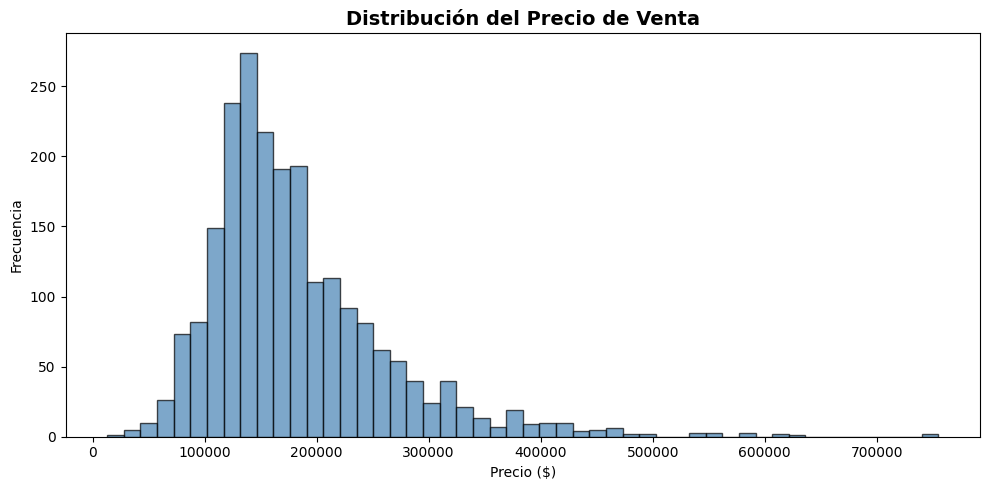


=== ESTADÍSTICAS DEL TARGET ===


,SalePrice
count,2197.000000
mean,182376.851161
std,81168.157405
min,13100.000000
25%,130000.000000
50%,163500.000000
75%,215000.000000
max,755000.000000



Skewness: 1.78
Nota: Skewness > 1 indica distribución asimétrica hacia la derecha (muchos valores bajos, pocos muy altos)


In [84]:
# Distribución del target
plt.figure(figsize=(10, 5))
plt.hist(df['SalePrice'], bins=50, color='steelblue', edgecolor='black', alpha=0.7)
plt.title('Distribución del Precio de Venta', fontsize=14, fontweight='bold')
plt.xlabel('Precio ($)')
plt.ylabel('Frecuencia')
plt.tight_layout()
plt.show()

# Estadísticas del target
print("\n=== ESTADÍSTICAS DEL TARGET ===")
display(df['SalePrice'].describe().to_frame())
print(f"\nSkewness: {df['SalePrice'].skew():.2f}")
print("Nota: Skewness > 1 indica distribución asimétrica hacia la derecha (muchos valores bajos, pocos muy altos)")

---
# LIMPIEZA DE DATOS

## Tratamiento de Valores Faltantes

In [85]:
df_clean = df.copy()

# Variables donde NaN significa "no tiene" (características ausentes)
none_cols = ['PoolQC', 'MiscFeature', 'Alley', 'Fence', 'FireplaceQu',
             'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond',
             'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'MasVnrType']

for col in none_cols:
    if col in df_clean.columns:
        df_clean[col] = df_clean[col].fillna('None')

# Variables numéricas donde NaN = 0 (no tiene esa característica)
zero_cols = ['GarageYrBlt', 'GarageArea', 'GarageCars', 'BsmtFinSF1', 'BsmtFinSF2', 
             'BsmtUnfSF', 'TotalBsmtSF', 'BsmtFullBath', 'BsmtHalfBath', 'MasVnrArea']

for col in zero_cols:
    if col in df_clean.columns:
        df_clean[col] = df_clean[col].fillna(0)

# Para el resto de columnas con nulos: imputar con mediana (numéricas) o moda (categóricas)
for col in df_clean.columns:
    if df_clean[col].isnull().sum() > 0:
        if df_clean[col].dtype in ['float64', 'int64']:
            df_clean[col] = df_clean[col].fillna(df_clean[col].median())
        else:
            df_clean[col] = df_clean[col].fillna(df_clean[col].mode()[0])

# Verificar
remaining_nulls = df_clean.isnull().sum().sum()
print(f"Valores faltantes después de limpieza: {remaining_nulls}")

if remaining_nulls == 0:
    print("✅ Todos los valores faltantes fueron tratados")
else:
    print(f"⚠️ Quedan {remaining_nulls} valores faltantes")

Valores faltantes después de limpieza: 0
✅ Todos los valores faltantes fueron tratados


## Tratamiento de Outliers

In [86]:
# Detectar outliers extremos en GrLivArea (área habitable)
# Casas muy grandes con precio muy bajo son anómalas

if 'GrLivArea' in df_clean.columns:
    outliers = df_clean[(df_clean['GrLivArea'] > 4000) & (df_clean['SalePrice'] < 300000)]
    print(f"Outliers detectados: {len(outliers)}")
    
    if len(outliers) > 0:
        df_clean = df_clean.drop(outliers.index)
        print(f"✅ Outliers eliminados. Nuevo shape: {df_clean.shape}")
    else:
        print("✅ No se detectaron outliers extremos")

Outliers detectados: 3
✅ Outliers eliminados. Nuevo shape: (2194, 82)


---
# PREPROCESAMIENTO

## Encoding de Variables Categóricas

In [87]:
df_encoded = df_clean.copy()

# Encoding ordinal para variables de calidad (tienen orden lógico)
quality_map = {'None': 0, 'Po': 1, 'Fa': 2, 'TA': 3, 'Gd': 4, 'Ex': 5}
quality_cols = ['ExterQual', 'ExterCond', 'BsmtQual', 'BsmtCond', 'HeatingQC', 
                'KitchenQual', 'FireplaceQu', 'GarageQual', 'GarageCond', 'PoolQC']

for col in quality_cols:
    if col in df_encoded.columns:
        df_encoded[col] = df_encoded[col].map(quality_map)
        df_encoded[col] = df_encoded[col].fillna(0)  # Por si queda algún NaN

# One-Hot Encoding para el resto de variables categóricas
categorical_cols = df_encoded.select_dtypes(include=['object']).columns.tolist()
print(f"Variables categóricas a encodear: {len(categorical_cols)}")

for col in categorical_cols:
    # Crear dummies manualmente
    dummies = pd.get_dummies(df_encoded[col], prefix=col, drop_first=True)
    df_encoded = pd.concat([df_encoded, dummies], axis=1)
    df_encoded.drop(col, axis=1, inplace=True)

print(f"\n✅ Encoding completado")
print(f"Shape después de encoding: {df_encoded.shape}")

Variables categóricas a encodear: 33

✅ Encoding completado
Shape después de encoding: (2194, 242)


## Separar Features y Target

In [88]:
# Target
y = df_encoded['SalePrice'].values

# Features (todas excepto el target)
X = df_encoded.drop('SalePrice', axis=1).values

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")
print(f"\nNombre de features (primeras 10):")
print(df_encoded.drop('SalePrice', axis=1).columns.tolist()[:10])

X shape: (2194, 241)
y shape: (2194,)

Nombre de features (primeras 10):
['Order', 'PID', 'MSSubClass', 'LotFrontage', 'LotArea', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemod/Add', 'MasVnrArea']


## Train-Test Split Manual (80-20)

In [89]:
# Configuración
np.random.seed(42)
test_size = 0.2

# Generar índices aleatorios
n_samples = len(X)
indices = np.random.permutation(n_samples)

# Calcular punto de corte
test_size_abs = int(n_samples * test_size)
train_size_abs = n_samples - test_size_abs

# Dividir índices
train_indices = indices[:train_size_abs]
test_indices = indices[train_size_abs:]

# Crear conjuntos
X_train = X[train_indices]
X_test = X[test_indices]
y_train = y[train_indices]
y_test = y[test_indices]

print(f"✅ Split completado")
print(f"Train: {X_train.shape[0]} muestras")
print(f"Test: {X_test.shape[0]} muestras")
print(f"\nPrecio promedio Train: ${y_train.mean():,.2f}")
print(f"Precio promedio Test: ${y_test.mean():,.2f}")

✅ Split completado
Train: 1756 muestras
Test: 438 muestras

Precio promedio Train: $182,723.47
Precio promedio Test: $181,029.50


## Escalado Manual (StandardScaler)

Fórmula: `x_scaled = (x - mean) / std`

**IMPORTANTE**: Calcular media y desviación estándar SOLO con datos de entrenamiento para evitar data leakage.

In [90]:

X_train = X_train.astype(float)
X_test = X_test.astype(float)


# Calcular media y desviación estándar del TRAIN set
mean_train = X_train.mean(axis=0)
std_train = X_train.std(axis=0)

# Evitar división por cero (columnas constantes)
std_train[std_train == 0] = 1

# Aplicar escalado
X_train_scaled = (X_train - mean_train) / std_train
X_test_scaled = (X_test - mean_train) / std_train  # Usar estadísticas del train

# Convertir a float explícitamente (prevenir errores de tipo)
X_train_scaled = X_train_scaled.astype(float)
X_test_scaled = X_test_scaled.astype(float)

print("✅ Escalado completado")
print(f"\nMedia de X_train_scaled (primeras 5 features): {X_train_scaled.mean(axis=0)[:5]}")
print(f"Desv. Std de X_train_scaled (primeras 5 features): {X_train_scaled.std(axis=0)[:5]}")

✅ Escalado completado

Media de X_train_scaled (primeras 5 features): [-1.36723080e-18 -2.11928678e-16  3.90095448e-17 -2.70221709e-16
  1.27018113e-16]
Desv. Std de X_train_scaled (primeras 5 features): [1. 1. 1. 1. 1.]


---
# VALIDACIÓN FINAL

## 1. Verificar Data Leakage

In [91]:
# Verificar que no hay índices compartidos entre train y test
shared_indices = np.intersect1d(train_indices, test_indices)

if len(shared_indices) == 0:
    print("✅ No hay data leakage (índices únicos en train y test)")
else:
    print(f"⚠️ ALERTA: {len(shared_indices)} índices compartidos detectados")

✅ No hay data leakage (índices únicos en train y test)


## 2. Verificar NaN e Infinitos

In [92]:
# Verificar NaN
nan_train = np.isnan(X_train_scaled).sum()
nan_test = np.isnan(X_test_scaled).sum()

# Verificar infinitos
inf_train = np.isinf(X_train_scaled).sum()
inf_test = np.isinf(X_test_scaled).sum()

print(f"NaN en X_train_scaled: {nan_train}")
print(f"NaN en X_test_scaled: {nan_test}")
print(f"Infinitos en X_train_scaled: {inf_train}")
print(f"Infinitos en X_test_scaled: {inf_test}")

if nan_train == 0 and nan_test == 0 and inf_train == 0 and inf_test == 0:
    print("\n✅ Datos limpios (sin NaN ni infinitos)")
else:
    print("\n⚠️ ALERTA: Hay NaN o infinitos en los datos")

NaN en X_train_scaled: 0
NaN en X_test_scaled: 0
Infinitos en X_train_scaled: 0
Infinitos en X_test_scaled: 0

✅ Datos limpios (sin NaN ni infinitos)


## 3. Comparar Distribuciones Train vs Test

In [93]:
# Comparar media y std de las primeras 5 features
print("=== COMPARACIÓN TRAIN vs TEST (primeras 5 features) ===")
print("\nMEDIA:")
print(f"Train: {X_train_scaled.mean(axis=0)[:5]}")
print(f"Test:  {X_test_scaled.mean(axis=0)[:5]}")

print("\nDESVIACIÓN ESTÁNDAR:")
print(f"Train: {X_train_scaled.std(axis=0)[:5]}")
print(f"Test:  {X_test_scaled.std(axis=0)[:5]}")

print("\n✅ Las distribuciones deberían ser similares (train estandarizado, test escalado con stats de train)")

=== COMPARACIÓN TRAIN vs TEST (primeras 5 features) ===

MEDIA:
Train: [-1.36723080e-18 -2.11928678e-16  3.90095448e-17 -2.70221709e-16
  1.27018113e-16]
Test:  [ 0.02290666  0.00651133  0.00833834 -0.10834588  0.08244815]

DESVIACIÓN ESTÁNDAR:
Train: [1. 1. 1. 1. 1.]
Test:  [1.01492376 1.00104539 0.96722506 1.02808423 1.69601844]

✅ Las distribuciones deberían ser similares (train estandarizado, test escalado con stats de train)


## Resumen Final

In [94]:
print("="*60)
print("RESUMEN DEL PREPROCESAMIENTO")
print("="*60)
print(f"Dataset original: {df.shape}")
print(f"Dataset después de limpieza: {df_clean.shape}")
print(f"Features después de encoding: {X.shape[1]}")
print(f"Train set: {X_train_scaled.shape}")
print(f"Test set: {X_test_scaled.shape}")
print(f"\nTarget (precio de venta):")
print(f"  - Mínimo: ${y.min():,.0f}")
print(f"  - Promedio: ${y.mean():,.0f}")
print(f"  - Máximo: ${y.max():,.0f}")
print(f"\n✅ Datos listos para entrenamiento de modelos de regresión")
print("="*60)

RESUMEN DEL PREPROCESAMIENTO
Dataset original: (2197, 82)
Dataset después de limpieza: (2194, 82)
Features después de encoding: 241
Train set: (1756, 241)
Test set: (438, 241)

Target (precio de venta):
  - Mínimo: $13,100
  - Promedio: $182,385
  - Máximo: $755,000

✅ Datos listos para entrenamiento de modelos de regresión
